In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#stimulate 60 days of defect data
np.random.seed(42)
days = pd.date_range(start='2024-01-01', periods=60)
sample_size = np.random.randint(80, 120, size=60) #daily sample size
true_defect_rate = 0.05

#simulate daily defect counts
defect_counts = np.random.binomial(sample_size, true_defect_rate)

df = pd.DataFrame({
     'Date': days,
     'Sample Size': sample_size,
     'Defects': defect_counts
     })
df['Defect_Rate'] = df['Defects'] / df['Sample Size']
print(df.head())

        Date  Sample Size  Defects  Defect_Rate
0 2024-01-01          118        5     0.042373
1 2024-01-02          108        9     0.083333
2 2024-01-03           94        6     0.063830
3 2024-01-04           87        3     0.034483
4 2024-01-05          100        5     0.050000


In [ ]:
#overall average defect rate(beta)
p_bar = df['Defects'].sum() / df['Sample Size'].sum()

#Control limit (3 sigma)
df['p_bar'] = p_bar
df['UCL'] = p_bar + 3 * np.sqrt(p_bar * (1 - p_bar) / df['Sample Size'])
df['LCL'] = p_bar - 3 * np.sqrt(p_bar * (1 - p_bar) / df['Sample Size'])
df['LCL'] = df['LCL'].clip(lower=0) #LCL can't be negative

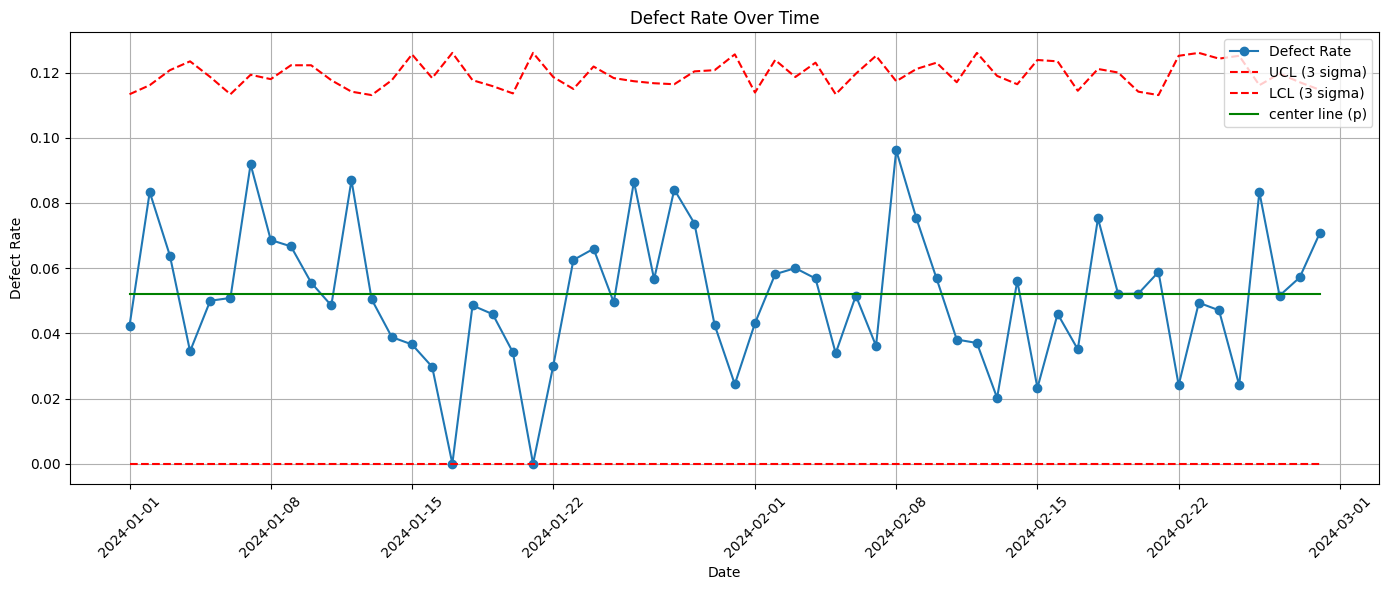

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Defect_Rate'], label='Defect Rate',marker='o')
plt.plot(df['Date'], df['UCL'], label='UCL (3 sigma)', linestyle='--',color = 'red')
plt.plot(df['Date'], df['LCL'], label='LCL (3 sigma)', linestyle='--', color = 'red')
plt.plot(df['Date'], df['p_bar'], label='center line (p)', linestyle = '-', color = 'green')
plt.xlabel('Date')
plt.ylabel('Defect Rate')
plt.title('Defect Rate Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df['Out_of_Control'] = (df['Defect_Rate'] > df['UCL']) | (df['Defect_Rate'] < df['LCL'])

#show flagged days
print(df[df['Out_of_Control']][['Date','Defect_Rate','UCL','LCL']])

Empty DataFrame
Columns: [Date, Defect_Rate, UCL, LCL]
Index: []


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

#test if last days defect rate is significantly higher than average
last = df.iloc[-1]
count = last['Defects']
nobs = last['Sample Size']
stat,pval = proportions_ztest(count, nobs, p_bar , alternative='larger')
print(f"Z-statistic: {stat}")
print(f"P-value: {pval}")

if pval < 0.05:
    print("Reject the null hypothesis. Last days defect rate is significantly higher than average.")
else:
    print("Fail to reject the null hypothesis. Last days defect rate is not significantly higher than average.")

Z-statistic: 0.7785554551105645
P-value: 0.21812081386484877
Fail to reject the null hypothesis. Last days defect rate is not significantly higher than average.


In [ ]:
# Introduce a shift in the defect rate on day 35
df.loc[35:, 'Defects'] = np.random.binomial(df.loc[35:, 'Sample Size'], 0.10) #doubled defect rate
df['Defect_Rate'] = df['Defects'  ] / df['Sample Size']

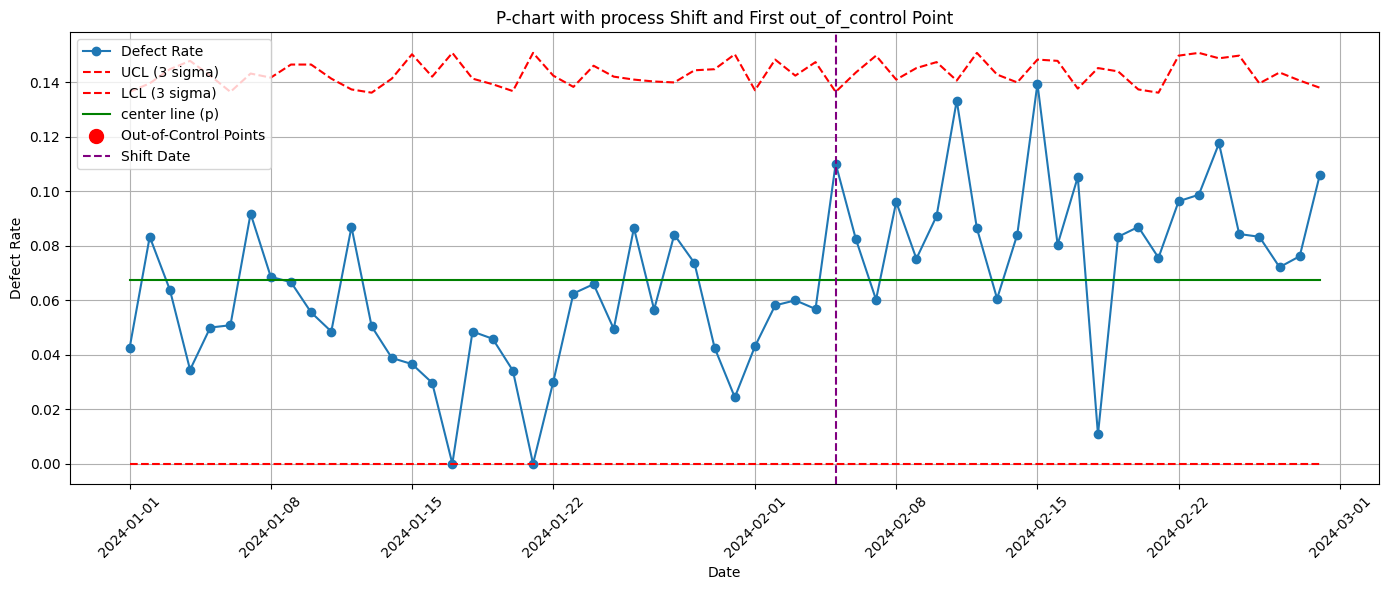

In [ ]:
# Recalculate p_bar and calculate Limits
p_bar = df['Defects'].sum() / df['Sample Size'].sum()
df['p_bar'] = p_bar
df['UCL'] = p_bar + 3 * np.sqrt(p_bar * (1 - p_bar) / df['Sample Size'])
df['LCL'] = p_bar - 3 * np.sqrt(p_bar * (1 - p_bar) / df['Sample Size'])
df['LCL'] = df['LCL'].clip(lower=0)

# Flaf out-of-control points
df['Out_of_Control'] = (df['Defect_Rate'] > df['UCL']) | (df['Defect_Rate'] < df['LCL'])
out_points = df[df['Out_of_Control']]

# identify first out-of-control point After the shift
first_shift_index = 35
first_out_after_shift = df.loc[first_shift_index:].query("Out_of_Control").head(1)

#plot setup
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Defect_Rate'], label='Defect Rate',marker='o')
plt.plot(df['Date'], df['UCL'], label='UCL (3 sigma)', linestyle='--',color = 'red')
plt.plot(df['Date'], df['LCL'], label='LCL (3 sigma)', linestyle='--', color = 'red')
plt.plot(df['Date'], df['p_bar'], label='center line (p)', linestyle = '-', color = 'green')
plt.scatter(out_points['Date'], out_points['Defect_Rate'], color='red', s=100, zorder=5, label='Out-of-Control Points')
plt.axvline(df['Date'].iloc[first_shift_index], color='purple', linestyle='--', label='Shift Date')

# Add annotation to first out-of-control point after shift
if not first_out_after_shift.empty:
  x = first_out_after_shift['Date'].values[0]
  y = first_out_after_shift['Defect_Rate'].values[0]
  plt.annotate(
      "First Out-of-Control Point After Shift",
      xy=(x, y),
      xytext=(x, y + 0.02),
      arrowprops=dict(facecolor='pink', shrink=0.05),
      fontsize = 10,
      ha='center'
      )

# Labels and Layout
plt.title('P-chart with process Shift and First out_of_control Point')
plt.xlabel('Date')
plt.ylabel('Defect Rate')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Step 1 : Estimate standard deviation for each row
df['sigma'] = np.sqrt((df['p_bar'] * (1-df['p_bar'])) / df['Sample Size'])

# Step 2 : Compute 1_sigma and 2_sigma boundaries
df['Upper_1sigma'] = df['p_bar'] + df['sigma']
df['Lower_1sigma'] = df['p_bar'] - df['sigma']
df['Upper_2sigma'] = df['p_bar'] + 2 * df['sigma']
df['Lower_2sigma'] = df['p_bar'] - 2 * df['sigma']

# Rule 1 : One point beyond UCL or LCL
df['Rule_1'] = (df['Defect_Rate'] > df['UCL']) | (df['Defect_Rate'] < df['LCL'])

# Rule 2 : 2 of 3 consecutive points beyond 2_sigma (same side)
rule2_flags = [False] * len(df)
for i in range(2, len(df)):
  upper = (df.loc[i-2:i, 'Defect_Rate'] > df.loc[i-2:i, 'Upper_2sigma']).sum()
  lower = (df.loc[i-2:i, 'Defect_Rate'] < df.loc[i-2:i, 'Lower_2sigma']).sum()
  rule2_flags[i] = (upper >= 2) or (lower >= 2)

df['Rule_2'] = rule2_flags

# Rule 4 : 8 points in a row on same side of center line
df['Above_Center'] = df['Defect_Rate'] > df['p_bar']
run_lenghts = [1]
for i in range(1, len(df)):
  if df.loc[i, 'Above_Center'] == df.loc[i-1, 'Above_Center']:
    run_lenghts.append(run_lenghts[-1] + 1)
  else:
    run_lenghts.append(1)
df['Run_Length'] = run_lenghts
df['Rule_4'] = df['Run_Length'] >= 8


# combine rules
df['Any_Rule_Violation'] = df[['Rule_1', 'Rule_2', 'Rule_4']].any(axis=1)

# View Violations
violations = df[df['Any_Rule_Violation']]
print(violations[['Date', 'Defect_Rate', 'Rule_1', 'Rule_2', 'Rule_4']])

         Date  Defect_Rate  Rule_1  Rule_2  Rule_4
19 2024-01-20     0.034188   False   False    True
20 2024-01-21     0.000000   False   False    True
21 2024-01-22     0.030000   False   False    True
22 2024-01-23     0.062500   False   False    True
23 2024-01-24     0.065934   False   False    True
24 2024-01-25     0.049505   False   False    True
56 2024-02-26     0.083333   False   False    True
57 2024-02-27     0.072165   False   False    True
58 2024-02-28     0.076190   False   False    True
59 2024-02-29     0.106195   False   False    True


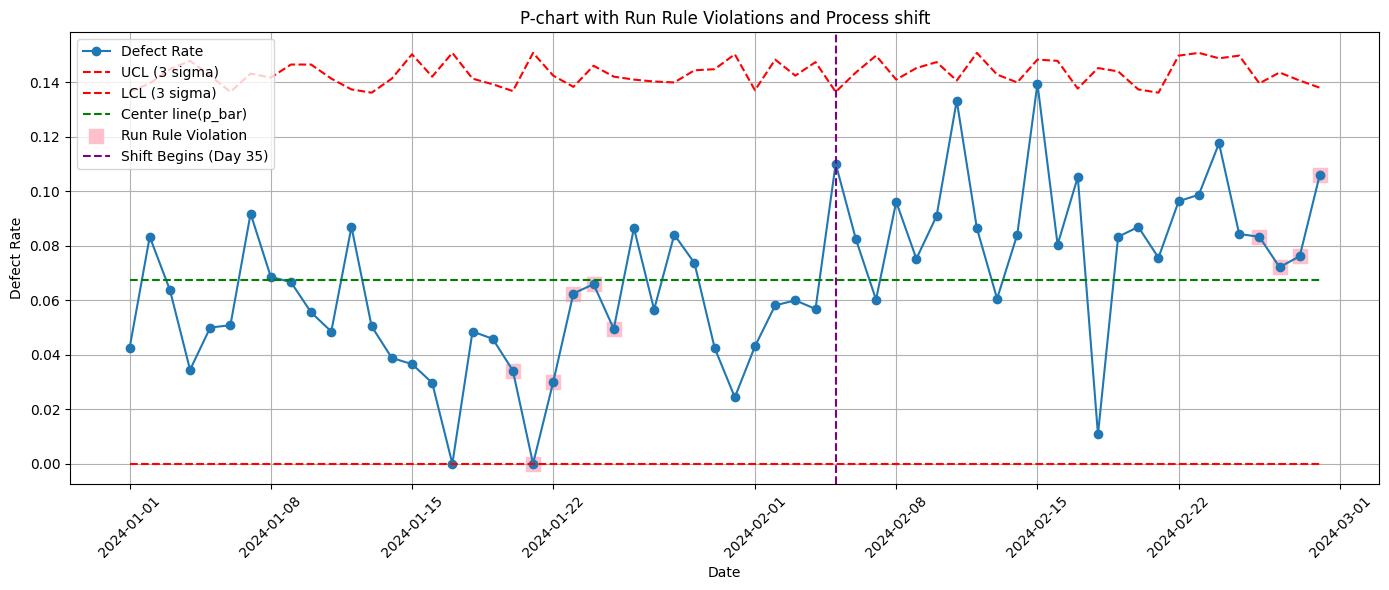

In [ ]:
# Plot with violation highlighted'
plt.figure(figsize=(14,6))

# Main defect rate line
plt.plot(df['Date'], df['Defect_Rate'], label='Defect Rate',marker='o')

# Control Limits and center
plt.plot(df['Date'], df['UCL'], label='UCL (3 sigma)', linestyle='--',color = 'red')
plt.plot(df['Date'], df['LCL'], label='LCL (3 sigma)', linestyle='--', color = 'red')
plt.plot(df['Date'], df['p_bar'], label='Center line(p_bar)', linestyle='--',color = 'green')

# Highlight violations
plt.scatter(violations['Date'], violations['Defect_Rate'], color='pink', s=100, marker='s', label='Run Rule Violation')

# Add Shift marker
plt.axvline(df['Date'].iloc[35], color='purple', linestyle='--', label='Shift Begins (Day 35)')

# Final touches
plt.title('P-chart with Run Rule Violations and Process shift')
plt.xlabel('Date')
plt.ylabel('Defect Rate')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Assume specs : acceptable defect rate between 2% and 8%
USL, LSL = 0.08, 0.02    #upper/lower specification limit
process_sigma = df['Defect_Rate'].std()

Cp = (USL - LSL) / (6 * process_sigma)
Cpk = min((USL - p_bar), (p_bar - LSL)) / (3 * process_sigma)

print(f"Cp value: {Cp:.2f}, Cpk value: {Cpk:.2f}")


Cp value: 0.34, Cpk value: 0.14


In [ ]:
boot_means = [np.mean(np.random.choice(df['Defect_Rate'], size=len(df), replace=True)) for _ in range(1000)]
ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

print(f"95% CI for average defect rate : ({ci_lower:.4f}, {ci_upper:.4f})")

95% CI for average defect rate : (0.0602, 0.0743)


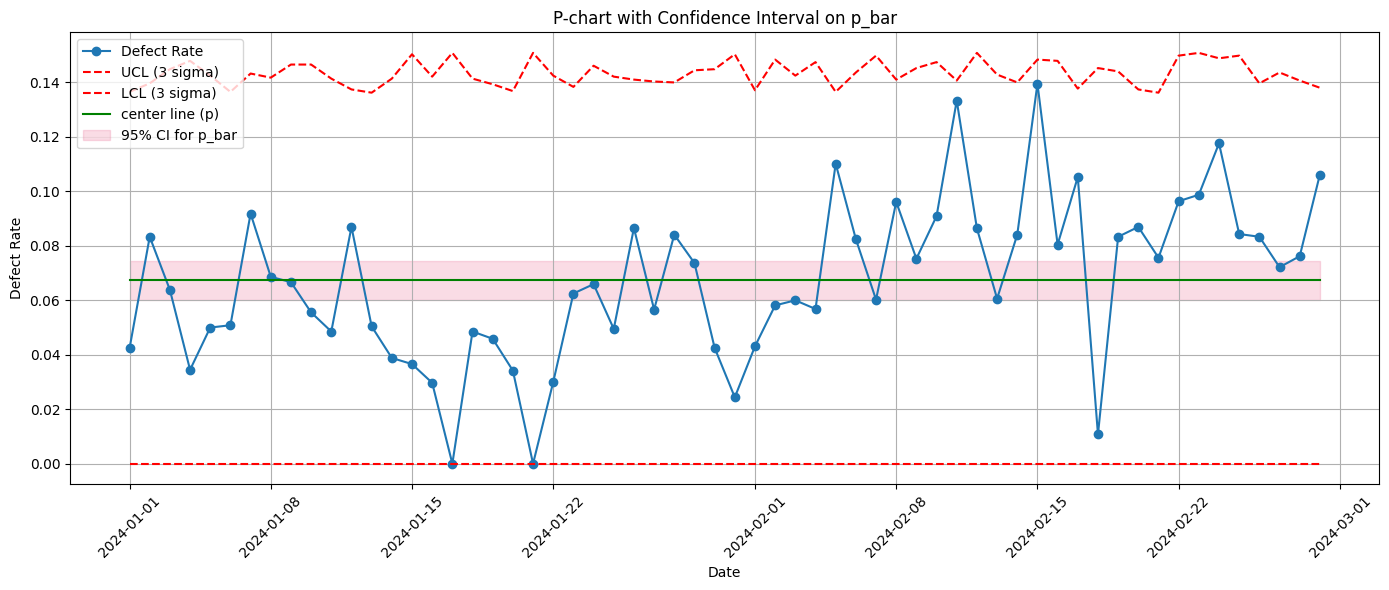

In [ ]:
# Existing chart
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Defect_Rate'], label='Defect Rate',marker='o')
plt.plot(df['Date'], df['UCL'], label='UCL (3 sigma)', linestyle='--',color = 'red')
plt.plot(df['Date'], df['LCL'], label='LCL (3 sigma)', linestyle='--', color = 'red')
plt.plot(df['Date'], df['p_bar'], label='center line (p)', linestyle = '-', color = 'green')

# Add this configure interval shading
plt.fill_between(df['Date'], ci_lower, ci_upper, color='#E75480', alpha=0.2, label='95% CI for p_bar')

# Finalize chart
plt.title('P-chart with Confidence Interval on p_bar')
plt.xlabel('Date')
plt.ylabel('Defect Rate')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

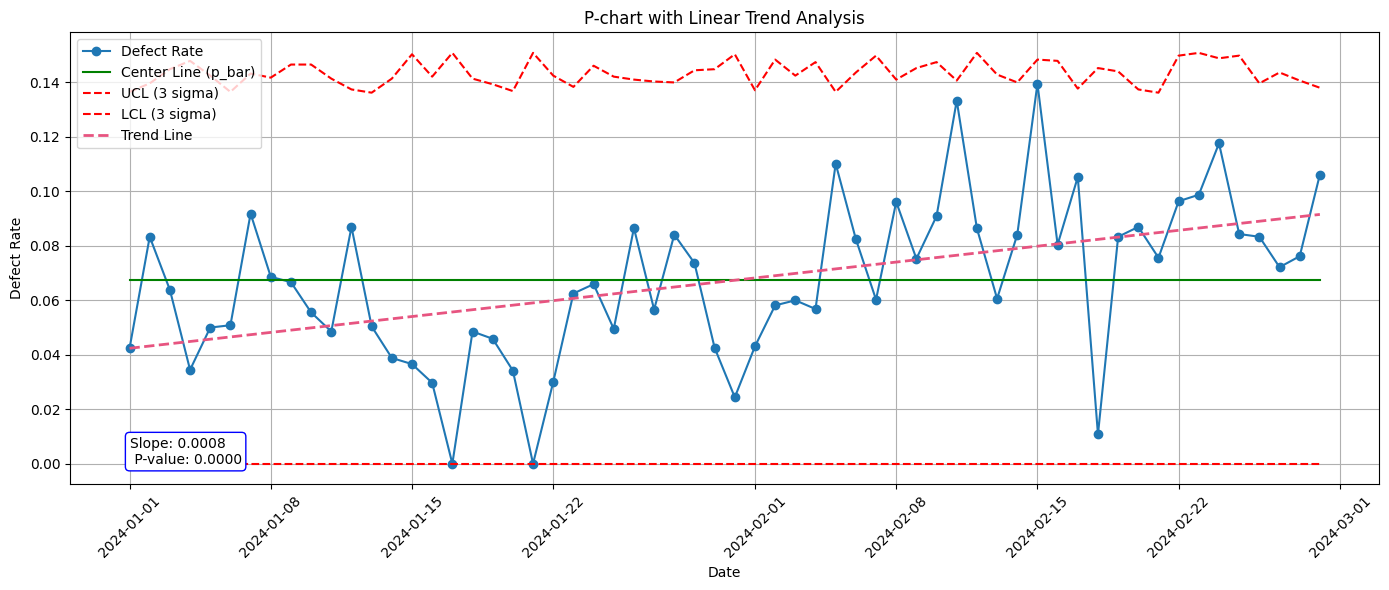

In [ ]:
from scipy.stats import linregress

# Step1 : Create a numeric "Day" column
df['Day'] = range(1, len(df) + 1)

# Step2 : Run linear regression on defect rate over time
trend_result = linregress(df['Day'], df['Defect_Rate'])

slope = trend_result.slope
p_value = trend_result.pvalue
intercept = trend_result.intercept

# Step 3 : Create trend line values
df['Trend_Line'] = intercept + slope * df['Day']

# Step 4 : Plot p-chart with trend line
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Defect_Rate'], label='Defect Rate',marker='o')
plt.plot(df['Date'], df['p_bar'], linestyle='-', color='green', label = 'Center Line (p_bar)')
plt.plot(df['Date'], df['UCL'], linestyle='--', color='red', label='UCL (3 sigma)')
plt.plot(df['Date'], df['LCL'], linestyle='--', color='red', label='LCL (3 sigma)')
plt.plot(df['Date'], df['Trend_Line'], linestyle='--', color='#E75480',linewidth=2, label='Trend Line')

# Step 5 : annotate with slope and p-value
plt.text(df['Date'].iloc[0], min(df['Defect_Rate']),
         f"Slope: {slope:.4f}\n P-value: {p_value:.4f}",
         fontsize=10, bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round'))

# Final touches
plt.title('P-chart with Linear Trend Analysis')
plt.xlabel('Date')
plt.ylabel('Defect Rate')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

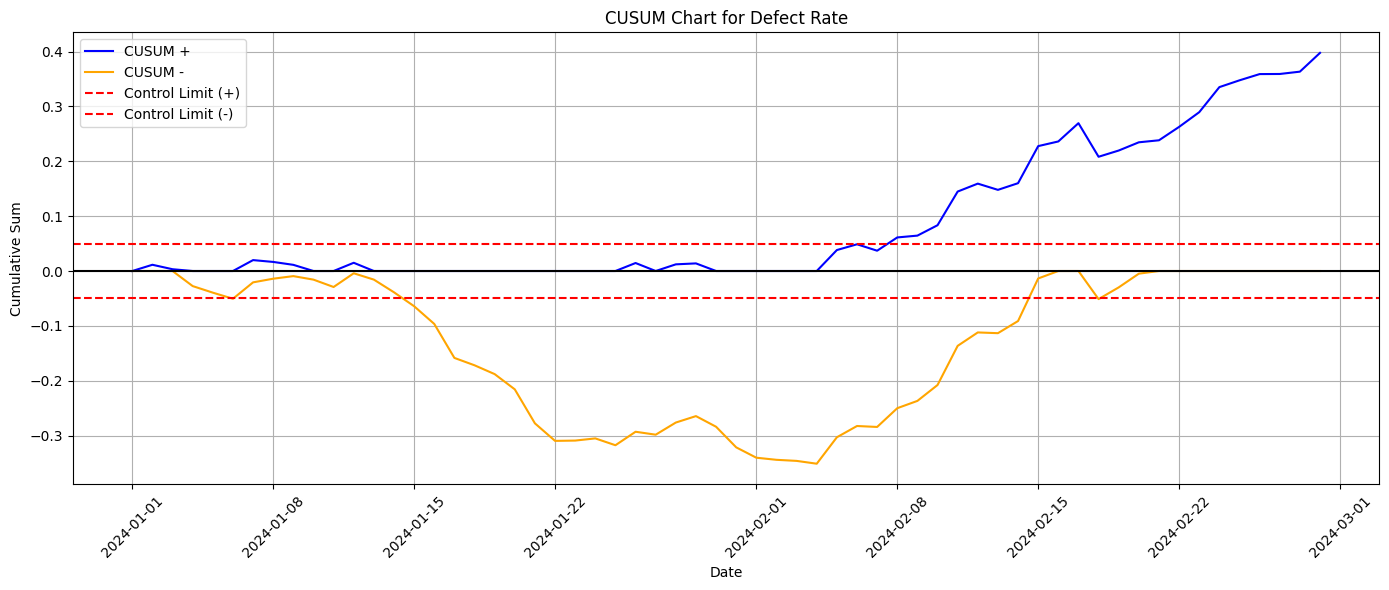

In [ ]:
# CUSUM Paramters
target = df['Defect_Rate'].mean()   #p_bar
k = 0.005   # Reference value (tuning sensivity)
h = 0.05    # decision threshold

# Intialize lines
cusum_pos = [0]
cusum_neg = [0]

# Calculate CUSUM values
for i in range(1, len(df)):
  p_i = df.loc[i, 'Defect_Rate']
  s_pos = max(0, cusum_pos[-1] + (p_i - target - k))
  s_neg = min(0, cusum_neg[-1] + (p_i - target + k))
  cusum_pos.append(s_pos)
  cusum_neg.append(s_neg)

# Add to Dataframe
df['CUSUM_pos'] = cusum_pos
df['CUSUM_neg'] = cusum_neg

# PLot CUSUM (Cumulative sum)
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['CUSUM_pos'], label='CUSUM +',color='blue')
plt.plot(df['Date'], df['CUSUM_neg'], label='CUSUM -',color='orange')
plt.axhline(h, color='red', linestyle='--', label='Control Limit (+)')
plt.axhline(-h, color='red', linestyle='--', label='Control Limit (-)')
plt.axhline(0, color='black', linestyle='-')
plt.title('CUSUM Chart for Defect Rate')
plt.xlabel('Date')
plt.ylabel('Cumulative Sum')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

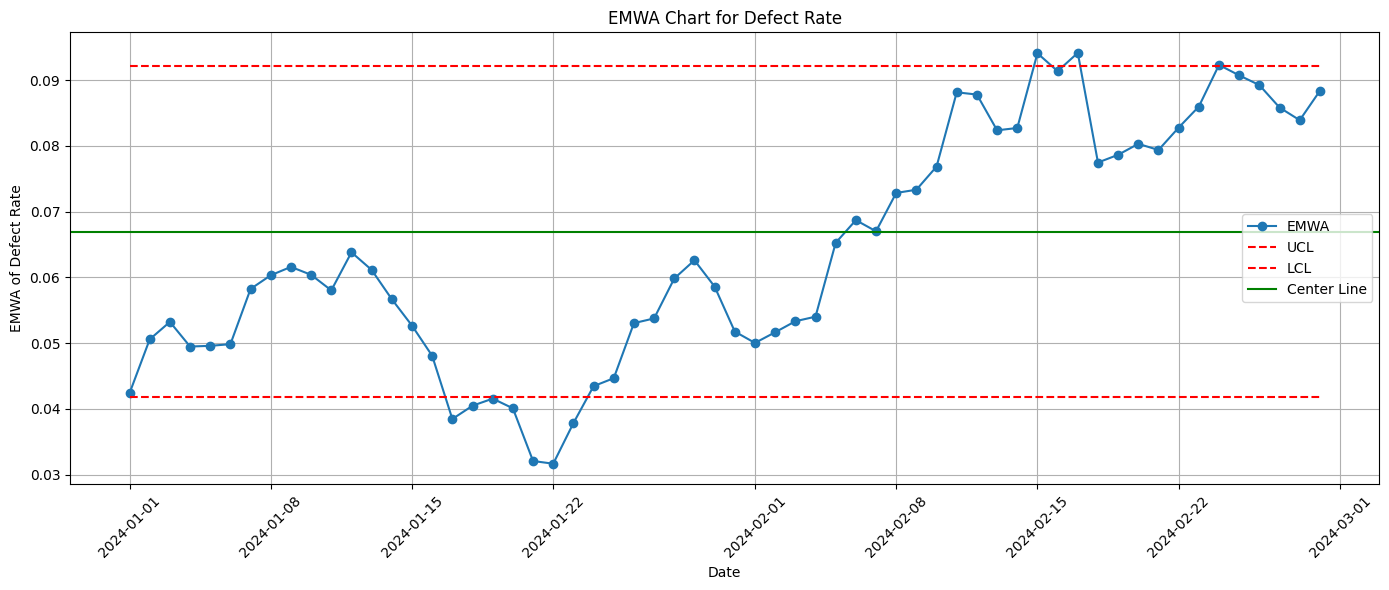

In [ ]:
# EMWA parameters
lambda_ = 0.2   # Smoothing constant (0.1-0.3 common)
L = 3           # Control Limit multiplier

# Initialize EMWA
df['EMWA'] = 0.0
df.loc[0, 'EMWA'] = df.loc[0, 'Defect_Rate']

# Compute EMWA for each day
for i in range(1, len(df)):
  df.loc[i, 'EMWA'] = lambda_ * df.loc[i, 'Defect_Rate'] + (1 - lambda_) * df.loc[i-1, 'EMWA']

# Estimate sigma (average over entire series)
p_bar = df['Defect_Rate'].mean()
avg_n = df['Sample Size'].mean()
sigma = np.sqrt(p_bar * (1 - p_bar) / avg_n)

# Control Limits
df['UCL_EMWA'] = p_bar + L * sigma * np.sqrt(lambda_ / (2 - lambda_))
df['LCL_EMWA'] = p_bar - L * sigma * np.sqrt(lambda_ / (2 - lambda_))

# PLot EMWA
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['EMWA'], label='EMWA',marker='o')
plt.plot(df['Date'], df['UCL_EMWA'], linestyle='--', color='red', label='UCL')
plt.plot(df['Date'], df['LCL_EMWA'], linestyle='--', color='red', label='LCL')
plt.axhline(p_bar, color='green', linestyle='-', label='Center Line')
plt.title('EMWA Chart for Defect Rate')
plt.xlabel('Date')
plt.ylabel('EMWA of Defect Rate')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

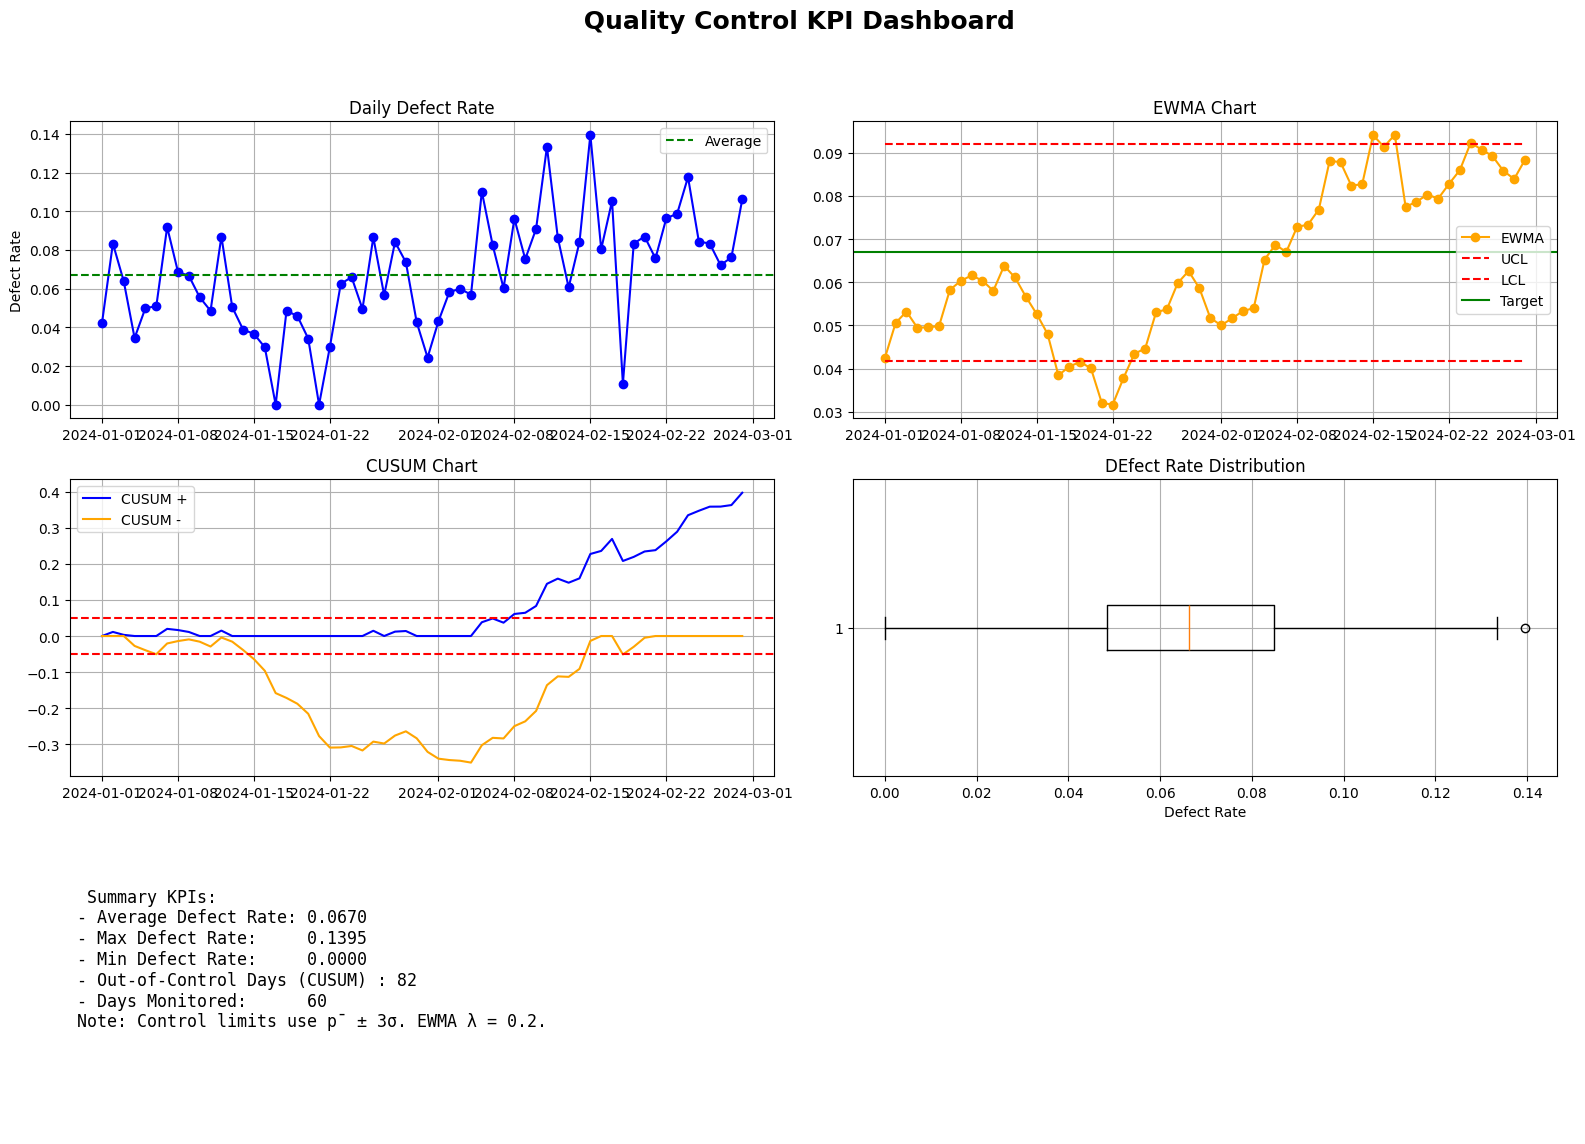

In [ ]:
# REcalculate needed KPIs
avg_defect_rate = df['Defect_Rate'].mean()
max_defect_rate = df['Defect_Rate'].max()
min_defect_rate = df['Defect_Rate'].min()
out_of_control_days = (df['CUSUM_pos'] > 0.05).sum() + (df['CUSUM_neg'] < 0.05).sum()

# Create subplot grids
fig, axs = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle(' Quality Control KPI Dashboard', fontsize=18, fontweight='bold')

# ----1. Daily Defect Rate
axs[0, 0].plot(df['Date'], df['Defect_Rate'], color='blue',marker='o')
axs[0, 0].axhline(avg_defect_rate, color='green', linestyle='--', label='Average')
axs[0, 0].set_title('Daily Defect Rate')
axs[0, 0].set_ylabel('Defect Rate')
axs[0, 0].legend()
axs[0, 0].grid(True)

# ----2. EWMA Chart
axs[0, 1].plot(df['Date'], df['EMWA'], color='orange',marker='o', label='EWMA')
axs[0, 1].plot(df['Date'], df['UCL_EMWA'], linestyle='--', color='red', label='UCL')
axs[0, 1].plot(df['Date'], df['LCL_EMWA'], linestyle='--', color='red', label='LCL')
axs[0, 1].axhline(avg_defect_rate, color='green', linestyle='-', label='Target')
axs[0, 1].set_title('EWMA Chart')
axs[0, 1].legend()
axs[0, 1].grid(True)

# ----3. CUSUM Chart
axs[1, 0].plot(df['Date'], df['CUSUM_pos'], color='blue', label='CUSUM +')
axs[1, 0].plot(df['Date'], df['CUSUM_neg'], color='orange', label='CUSUM -')
axs[1, 0].axhline(0.05, color='red', linestyle='--')
axs[1, 0].axhline(-0.05, color='red', linestyle='--')
axs[1, 0].set_title('CUSUM Chart')
axs[1, 0].legend()
axs[1, 0].grid(True)

# ----4. Boxplot of Defect Rates
axs[1, 1].boxplot(df['Defect_Rate'], vert=False)
axs[1, 1].set_title('DEfect Rate Distribution')
axs[1, 1].set_xlabel('Defect Rate')
axs[1, 1].grid(True)

# ----5. KPI Summary
axs [2, 0]. axis('off')
kpi_text = f"""
 Summary KPIs:
- Average Defect Rate: {avg_defect_rate:.4f}
- Max Defect Rate:     {max_defect_rate:.4f}
- Min Defect Rate:     {min_defect_rate:.4f}
- Out-of-Control Days (CUSUM) : {out_of_control_days}
- Days Monitored:      {len (df)}
Note: Control limits use p̄ ± 3σ. EWMA λ = 0.2.
"""
axs [2, 0].text(0.01, 0.9, kpi_text, fontsize=12, verticalalignment='top', family= 'monospace')

# ----6. Empty space or add more content ---
axs[2, 1].axis( 'off')        # Placeholder for future KPI
plt.tight_layout (rect=[0, 0.03, 1, 0.95])
plt.show()